<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/nprivaul/fractionalpdes/blob/master/fujita-type.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

This code solves the time-fractional Fujita-type equation 
$$\partial_t^\alpha u=-(-\Delta u)^{\gamma/2}+\lambda (p_0+p_1 u+\cdots +p_N u^N)$$ 
on the whole space $\mathbb{R}^d$ with initial condition $f$, $\lambda>0$, $p_k\in [0,1]$, $p_0+\cdots +p_N=1$ and $(\alpha , \gamma) = (0.5,0.5)$ or $(\alpha , \gamma ) = ( 0.5,2/3)$.

In [1]:
import math
import matplotlib.pyplot as plt
from scipy.stats import expon,uniform,norm
import numpy as np
from scipy.special import gammaln

plt.rcParams.update({
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 16,
    "legend.title_fontsize": 14,
    "xtick.major.pad": 8,        # Increase distance between x-axis and tick labels (default ~4)
    "figure.titlesize": 24,
    "axes.xmargin": 0,      # Equivalent to ax.margins(x=0)
    "figure.autolayout": True,  # Equivalent to plt.tight_layout()
})

Progress: 1/21
Progress: 2/21
Progress: 3/21
Progress: 4/21
Progress: 5/21
Progress: 6/21
Progress: 7/21
Progress: 8/21
Progress: 9/21
Progress: 10/21
Progress: 11/21
Progress: 12/21
Progress: 13/21
Progress: 14/21
Progress: 15/21
Progress: 16/21
Progress: 17/21
Progress: 18/21
Progress: 19/21
Progress: 20/21
Progress: 21/21


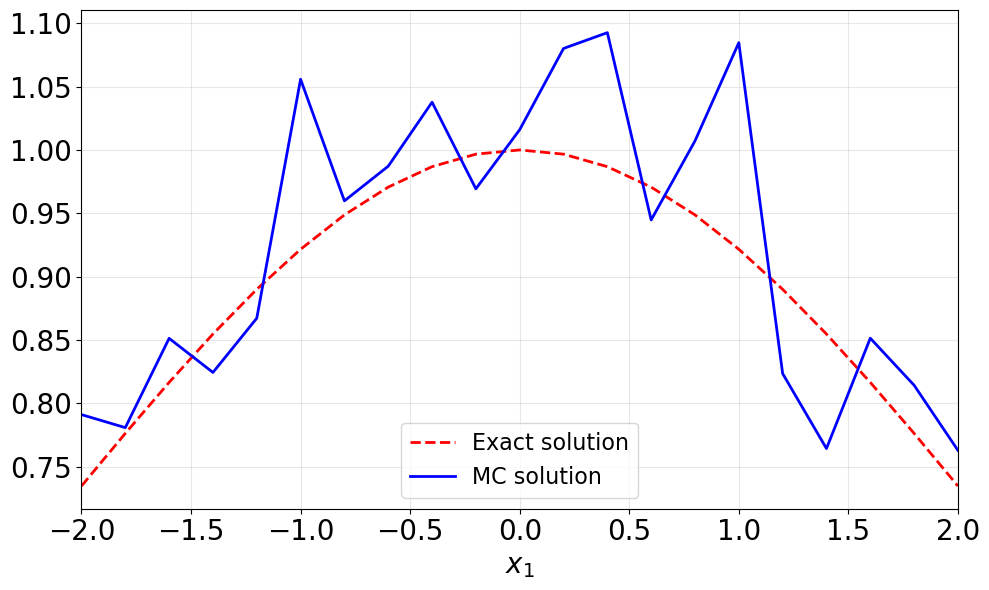

Progress: 1/21
Progress: 2/21
Progress: 3/21
Progress: 4/21
Progress: 5/21
Progress: 6/21
Progress: 7/21
Progress: 8/21
Progress: 9/21
Progress: 10/21
Progress: 11/21
Progress: 12/21
Progress: 13/21
Progress: 14/21
Progress: 15/21
Progress: 16/21
Progress: 17/21
Progress: 18/21
Progress: 19/21
Progress: 20/21
Progress: 21/21


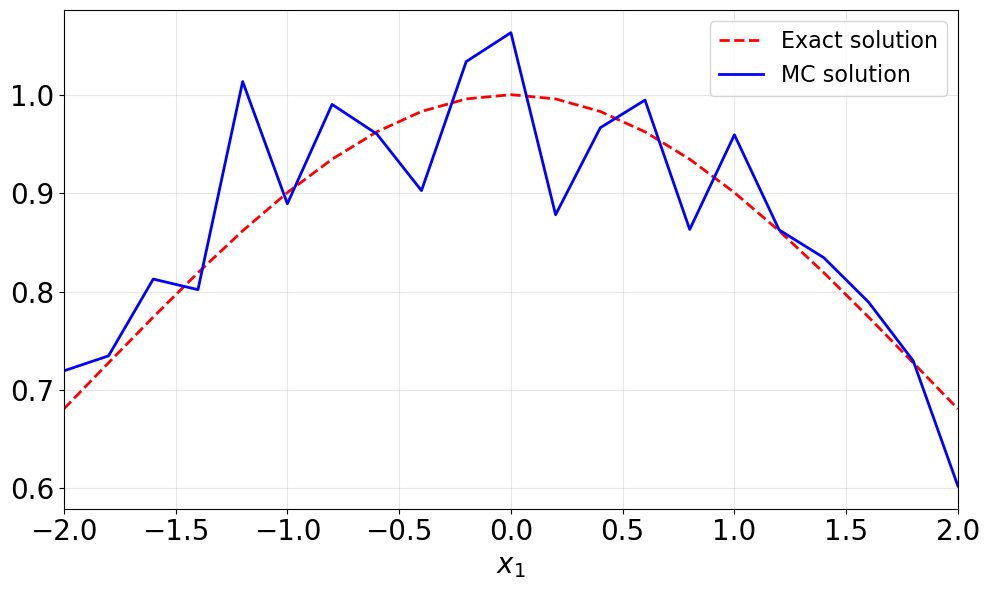

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Thu Feb 26 19:50:07 2026

@author: gerar
"""

#=============================================================================
#MC ALGORITHM
#=============================================================================
def f(x,d,gamma): 
    """
    Initial condition - a function from R^d to [0,1]
    x=[x[1],...,x[d]] is an array if d>1; if d=1, x must be a float
    This initial condition leads to a stationary solution, useful for comparing the MC algorithm
    """
    A=1
    c=[0 for i in range(d)]
    normx=np.linalg.norm(np.array(x)-np.array(c))
    log_ratio=gammaln((d-gamma)/2)-gammaln((d+gamma)/2)
    ratio=np.exp(log_ratio/gamma)
    return A*(1.0+(0.5*A**(2/(d-gamma))*normx*ratio)**2)**((gamma-d)/2) 

def subordinator_rv(alpha):
    """
    This simulates S(1), where (S(t))_t is an \alpha-stable subordinator (Chambers, Mallows, Stuck (1976))
    alpha is a number in (0,1]
    """
    if alpha==1:
        return 1
    else:
        theta=math.pi*uniform.rvs()
        w=expon.rvs()
        aux1=math.sin((1-alpha)*theta)*(math.sin(alpha*theta))**(alpha/(1-alpha))
        aux2=(math.sin(theta))**(1/(1-alpha))
        aux3=aux1/aux2
        return (aux3/w)**((1-alpha)/alpha)

    
def stable_rv(gamma,d,t):
    """
    This simulates X(t), where (X(t))_t is a d-dimensional symmetric gamma-stable process
    gamma is a number in (0,2], d is a natural number, t geq 0
    If d==1, the output is a float; if d>1, it is an array 
    """
    if d==1:
        return norm.rvs()*(2*subordinator_rv(gamma/2))**(1/2)*t**(1/gamma)  #Scaling property
    else:
       aux1=norm.rvs(size=d)
       aux2=subordinator_rv(gamma/2)
       return [aux1[i]*(2*aux2)**(1/2)*t**(1/gamma) for i in range(d)]
   
def discrete_rv(p):
    """
    This simulates a random variable on {0,1,..., N}, N>1, according to law [p_0,p_1,...,p_N]
    p_k is a number in [0,1] and p_0+p_1+...+p_N=1
    """
    aux=0
    u=uniform.rvs()
    for i in range(len(p)):
        if u<aux+p[i]:
            return i
        else:
            aux=aux+p[i]
 
def branching(alpha,gamma,lam,p,d,x,T):
    """
    This simulates the random variable U=e^{lambda W_t^alpha} prod_{k in mathcal{N}_t^alpha}f(x+Y_k^alpha(t))
    alpha,gam,lam,p,d are as in "PARAMETERS"
    x=[x[1],...,x[d]] is an array representing a point, T is a positive number representing time
    """
    s1=subordinator_rv(alpha)
    tau=expon.rvs()/lam                             #Exponential lifetime 
    sigma=s1*tau**(1/alpha)                         #Mittag Leffler lifetime
    if sigma>T:                                     #No branching case
        et=(T/s1)**alpha                            #Inverse stable subordinator law
        dx=stable_rv(gamma,d,et)                    #Spatial displacement
        if d==1:                                    #Dimension one case
            Y=x+dx                                  #Position at branching time
            return f(Y,d,gamma)*math.exp(lam*et)
        else:                                       #Dimension greater than one
            Y=[x[i]+dx[i] for i in range(d)]
            return f(Y,d,gamma)*math.exp(lam*et)
    else:                                           #Branching case
        branches=discrete_rv(p)                     #Number of branches
        aux=math.exp(lam*tau)
        dx=stable_rv(gamma,d,tau)                   
        if d==1:
            Y=x+dx
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma)    #Recursion
            return aux 
        else:
            Y=[x[i]+dx[i] for i in range(d)]
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma) 
            return aux
            
def mc_fujita_sol(alpha,gamma,lam,p,d,x,T,n_iter):   
    """
    This is the Monte Carlo estimator of the solution at (x,T)
    alpha,gam,lam,p,d are as in the section "Parameters"
    n_iter is the sample size
    """                      
    aux=0
    for i in range(n_iter):
        aux=aux+branching(alpha,gamma,lam,p,d,x,T)
    return aux/n_iter               #MC estimator

#==============================================================================
#EXAMPLE DIMENSION d=6
#==============================================================================
#PARMETERS
alpha=0.5   #time fractional order - a number in (0,1]
lam=1       #\lambda - a positive number
d=6         #dimension - a natural number (d=6 in this example)
gamma=2     #space fractional order- a number in (0,2]
p=[0,0,1]   #probability measure - p_k\in [0,1], p_0+...+p_n=1
n_iter=100    #sample size for MC algorith 
T=0.5          #time - a positive number
a=-2           #Interval [a,b] for x_1 (first coordinate)
b=2
nx1=21         #Number of points in [a,b]

#Space discretization
x1=[a+i*(b-a)/(nx1-1) for i in range(nx1)]      #Space discretization on axis x_1
x=[[x1[i],0,0,0,0,0] for i in range(nx1)]       #Selection of points on R^d

#MC estimator
y1 = [0 for i in range(nx1)]
for i in range(nx1):
    y1[i]=mc_fujita_sol(alpha,gamma,lam,p,d,x[i],T,n_iter)
    print(f"Progress: {i+1}/{nx1}")
    
#Initial condition for comparison
initial_condition= [f(x[i],d,gamma) for i in range(nx1)]
error=max([abs(y1[i]-initial_condition[i]) for i in range(nx1)])

#Plot results
plt.figure(figsize=(10, 6))
plt.plot(x1, initial_condition, 'r--', label='Exact solution', linewidth=2)
plt.plot(x1, y1, 'b-', label='MC solution', linewidth=2)
#plt.title(f"Time-Fractional Fujita Equation\n"rf"$\alpha={alpha}, d={d}, \gamma={round(gamma,3)}, \lambda={lam}, t={T}, N={n_iter}, p={p}, $""error"rf"$={round(error,3)}$")
plt.xlabel(r"$x_1$")
# plt.ylabel(r"$u(t,(x_1,0))$")
# plt.ylim(-0.001,1.001)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('fujita_d6.png', format='png', dpi=150)
plt.show()

#==============================================================================
#EXAMPLE DIMENSION d=5
#==============================================================================
#PARAMETERS
alpha=0.75
lam=1
d=5
gamma=5/3
p=[0,0,1] 
n_iter=100
T=0.5
a=-2       
b=2
nx1=21      

#Space discretization
x1=[a+i*(b-a)/(nx1-1) for i in range(nx1)]     #Space discretization on axis x_1
x=[[x1[i],0,0,0,0] for i in range(nx1)]        #Selection of points on R^d

#MC estimator
y1 = [0 for i in range(nx1)]
for i in range(nx1):
    y1[i]=mc_fujita_sol(alpha,gamma,lam,p,d,x[i],T,n_iter)
    print(f"Progress: {i+1}/{nx1}")
    
#Initial condition for comparison
initial_condition= [f(x[i],d,gamma) for i in range(nx1)]
error=max([abs(y1[i]-initial_condition[i]) for i in range(nx1)])

#Plot results
plt.figure(figsize=(10, 6))
plt.plot(x1, initial_condition, 'r--', label='Exact solution', linewidth=2)
plt.plot(x1, y1, 'b-', label='MC solution', linewidth=2)
#plt.title(f"Time-Fractional Fujita Equation\n"rf"$\alpha={alpha}, d={d}, \gamma={round(gamma,3)}, \lambda={lam}, t={T}, N={n_iter}, p={p}, $""error"rf"$={round(error,3)}$")
plt.xlabel(r"$x_1$")
# plt.ylabel(r"$u(t,(x_1,0))$")
# plt.ylim(-0.001,1.001)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('fujita_d5.png', format='png', dpi=150)
plt.show()

#==============================================================================
#MORE EXAMPLES
#==============================================================================

# #==============================================================================
# #EXAMPLE DIMENSION d=4, gamma=4/3
# #==============================================================================
# #PARAMETERS
# alpha=0.5
# lam=1
# d=4
# gamma=4/3
# p=[0,0,1] 
# n_iter=100
# T=0.5
# a=-1       
# b=1
# nx1=20     

# #Space discretization
# x1=[a+i*(b-a)/(nx1-1) for i in range(nx1)]      #Space discretization on axis x_1
# x=[[x1[i],0,0,0] for i in range(nx1)]           #Selection of point on R^d

# #MC estimator
# y1 = [0 for i in range(nx1)]
# for i in range(nx1):
#     y1[i]=mc_fujita_sol(alpha,gamma,lam,p,d,x[i],T,n_iter)
#     print(f"Progress: {i+1}/{nx1}")
    
# #Initial condition for comparison
# initial_condition= [f(x[i],d,gamma) for i in range(nx1)]
# error=max([abs(y1[i]-initial_condition[i]) for i in range(nx1)])

# #Plot results
# plt.figure(figsize=(10, 6))
# plt.plot(x1, initial_condition, 'r--', label='Exact solution', linewidth=2)
# plt.plot(x1, y1, 'b-', label='MC solution', linewidth=2)
# plt.title(f"Time-Fractional Fujita Equation\n"rf"$\alpha={alpha}, d={d}, \gamma={round(gamma,3)}, \lambda={lam}, t={T}, N={n_iter}, p={p}, $""error"rf"$={round(error,3)}$")
# plt.xlabel(r"$x_1$")
# plt.ylabel(r"$u(t,(x_1,0))$")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.savefig('fujita_d4_1.png', format='png', dpi=150)
# plt.show()
#
# #==============================================================================
# #EXAMPLE DIMENSION d=4, gamma=2
# #==============================================================================
# #PARAMETERS
# alpha=0.5
# lam=1
# d=4
# gamma=2
# p=[0,0,0,1] 
# n_iter=100
# T=0.5
# a=-1       
# b=1
# nx1=20      

# #Space discretization
# x1=[a+i*(b-a)/(nx1-1) for i in range(nx1)]     #Space discretization on axis x_1
# x=[[x1[i],0,0,0] for i in range(nx1)]        #Selection of point on R^d

# #MC estimator
# y1 = [0 for i in range(nx1)]
# for i in range(nx1):
#     y1[i]=mc_fujita_sol(alpha,gamma,lam,p,d,x[i],T,n_iter)
#     print(f"Progress: {i+1}/{nx1}")
    
# #Initial condition for comparison
# initial_condition= [f(x[i],d,gamma) for i in range(nx1)]
# error=max([abs(y1[i]-initial_condition[i]) for i in range(nx1)])

# #Plot results
# plt.figure(figsize=(10, 6))
# plt.plot(x1, initial_condition, 'r--', label='Exact solution', linewidth=2)
# plt.plot(x1, y1, 'b-', label='MC solution', linewidth=2)
# plt.title(f"Time-Fractional Fujita Equation\n"rf"$\alpha={alpha}, d={d}, \gamma={round(gamma,3)}, \lambda={lam}, t={T}, N={n_iter}, p={p}, $""error"rf"$={round(error,3)}$")
# plt.xlabel(r"$x_1$")
# plt.ylabel(r"$u(t,(x_1,0))$")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.savefig('fujita_d4_2.png', format='png', dpi=150)
# plt.show()

# #==============================================================================
# #EXAMPLE DIMENSION d=3, gamma=1
# #==============================================================================
# #PARAMETERS
# alpha=0.5
# lam=1
# d=3
# gamma=1
# p=[0,0,1] 
# n_iter=100
# T=0.5
# a=-1      
# b=1
# nx1=20      

# #Space discretization
# x1=[a+i*(b-a)/(nx1-1) for i in range(nx1)]     #Space discretization on axis x_1
# x=[[x1[i],0,0] for i in range(nx1)]        #Selection of point on R^d

# #MC estimator
# y1 = [0 for i in range(nx1)]
# for i in range(nx1):
#     y1[i]=mc_fujita_sol(alpha,gamma,lam,p,d,x[i],T,n_iter)
#     print(f"Progress: {i+1}/{nx1}")
    
# #Initial condition for comparison
# initial_condition= [f(x[i],d,gamma) for i in range(nx1)]
# error=max([abs(y1[i]-initial_condition[i]) for i in range(nx1)])

# #Plot results
# plt.figure(figsize=(10, 6))
# plt.plot(x1, initial_condition, 'r--', label='Exact solution', linewidth=2)
# plt.plot(x1, y1, 'b-', label='MC solution', linewidth=2)
# plt.title(f"Time-Fractional Fujita Equation\n"rf"$\alpha={alpha}, d={d}, \gamma={round(gamma,3)}, \lambda={lam}, t={T}, N={n_iter}, p={p}, $""error"rf"$={round(error,3)}$")
# plt.xlabel(r"$x_1$")
# plt.ylabel(r"$u(t,(x_1,0))$")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.savefig('fujita_d4_2.png', format='png', dpi=150)
# plt.show()



Running 1D case...


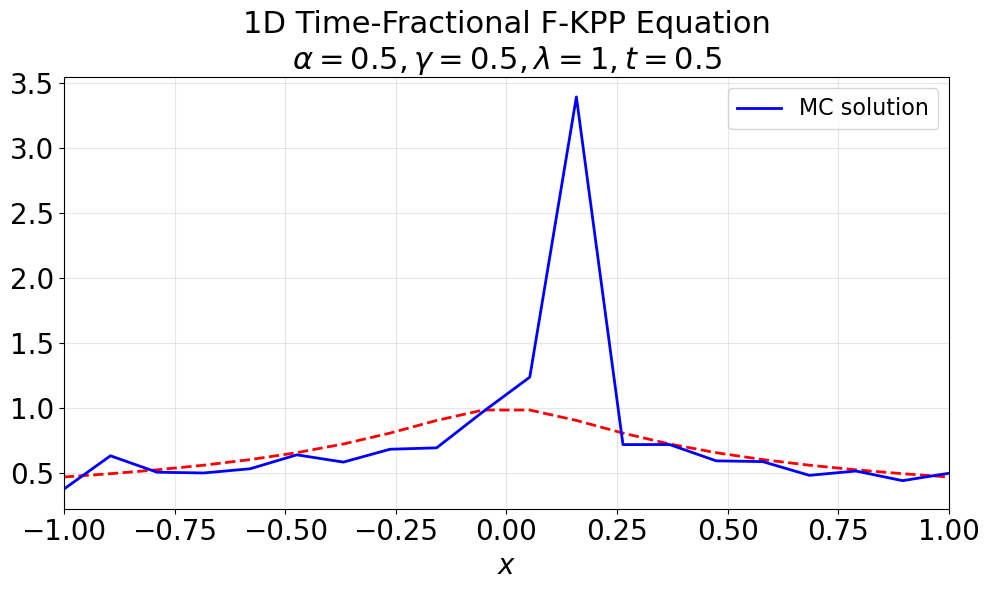

In [3]:
#==============================================================================
#Example - one dimensional case
#==============================================================================
print("Running 1D case...")

#PARAMETERS
alpha=0.5
lam=1
d=1
gamma=1/2
p=[0,0,0,1] 
n_iter=100
T=0.5
a=-1      
b=1
nx1=20 

#Space discretization
x_1d = [a+i*(b-a)/(nx1-1) for i in range(nx1)]    #Space discretization

#MC solution
y_1d = [mc_fujita_sol(alpha,gamma,lam,p,d,x_1d[i],T,n_iter) for i in range(len(x_1d))]

#Initial condition for comparison
initial_1d = [f(x_1d[i], d,gamma) for i in range(len(x_1d))]

#Plot 1D results
plt.figure(figsize=(10, 6))
#plt.plot(x_1d, initial_1d, 'r--', label='Initial condition', linewidth=2)
plt.plot(x_1d, initial_1d, 'r--', label='', linewidth=2)
plt.plot(x_1d, y_1d, 'b-', label='MC solution', linewidth=2)
plt.title(f"1D Time-Fractional F-KPP Equation\n"rf"$\alpha={alpha}, \gamma={gamma}, \lambda={lam}, t={T}$")
plt.xlabel(r"$x$")
# plt.ylabel(r"$u(t,x)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Running 2D case...
Computing 2D MC solution...
Progress: 1/15
Progress: 2/15
Progress: 3/15
Progress: 4/15
Progress: 5/15
Progress: 6/15
Progress: 7/15
Progress: 8/15
Progress: 9/15
Progress: 10/15
Progress: 11/15
Progress: 12/15
Progress: 13/15
Progress: 14/15
Progress: 15/15


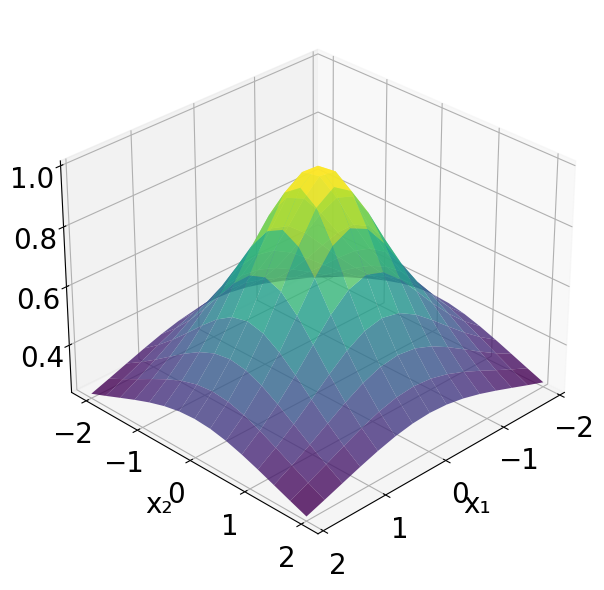

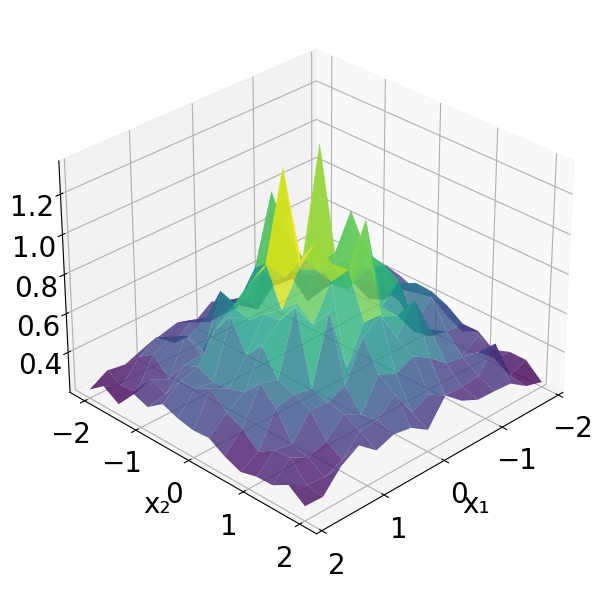

In [4]:
#==============================================================================
#Example - two dimensional case
#==============================================================================
print("Running 2D case...")

#PARAMETERS
alpha=0.5
lam=1
d=2
gamma=2/3
p=[0,0,1] 
n_iter=100
T=0.5

#Space discretization
a=-2        #Interval [a,b] x [c,dd] for [x1,x2]
b=2
c=-2
dd=2
nx1=15      #Number of points in [a,b] (reduced for speed)
nx2=15      #Number of ponts in [c,d] (reduced for speed)
x1=[a+i*(b-a)/(nx1-1) for i in range(nx1)]      #Space discretization x1
x2=[c+i*(dd-c)/(nx2-1) for i in range(nx2)]     #Space discretization x2

#Create meshgrid for plotting
X1, X2 = np.meshgrid(x1, x2, indexing='ij')

#Compute initial condition for comparison
initial_2d = np.zeros((nx1, nx2))
for i in range(nx1):
    for j in range(nx2):
        initial_2d[i, j] = f([x1[i], x2[j]], d,gamma)

#MC solution - this will take some time
print("Computing 2D MC solution...")
y_2d = np.zeros((nx1, nx2))
for i in range(nx1):
    print(f"Progress: {i+1}/{nx1}")
    for j in range(nx2):
        y_2d[i, j] = mc_fujita_sol(alpha, gamma, lam, p, d, [x1[i], x2[j]], T, n_iter)

# Error
error=np.max([[ initial_2d[i, j]-y_2d[i, j] for j in range(nx2)] for i in range(nx1)])

# # Create comprehensive 3-panel visualization like the previous code
# fig = plt.figure(figsize=(15,6))

# # Panel 1: Initial condition (3D surface)
# ax1 = fig.add_subplot(121, projection='3d')
# surf1 = ax1.plot_surface(X1, X2, initial_2d, cmap='viridis', alpha=0.8, linewidth=0)
# ax1.set_title('Initial Condition')
# ax1.set_xlabel('x₁')
# ax1.set_ylabel('x₂')
# ax1.set_zlabel('u(0,x)')
# ax1.view_init(elev=30, azim=45)

# # Panel 2: Final solution (3D surface)
# ax2 = fig.add_subplot(122, projection='3d')
# surf2 = ax2.plot_surface(X1, X2, y_2d, cmap='viridis', alpha=0.8, linewidth=0)
# ax2.set_title(f'MC Solution at t = {T}\n'rf"$\alpha={alpha}, \gamma={round(gamma,3)}, \lambda={lam}, N={n_iter}, p={p}, $"f"Error={round(error,4)}")
# ax2.set_xlabel('x₁')
# ax2.set_ylabel('x₂')
# ax2.set_zlabel(f'u({T},x)')
# ax2.view_init(elev=30, azim=45)

# plt.tight_layout()
# plt.savefig('2dplot1.png', format='png', dpi=150)
# plt.show()

fig1 = plt.figure(figsize=(7,6))
ax1 = fig1.add_subplot(111, projection='3d')

surf1 = ax1.plot_surface(X1, X2, initial_2d, cmap='viridis', alpha=0.8, linewidth=0)

# ax1.set_title('Initial Condition')
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
#ax1.set_zlabel('u(0,x)')
ax1.view_init(elev=30, azim=45)

plt.tight_layout()
plt.savefig('initial_condition.png', format='png', dpi=150)
plt.show()

fig2 = plt.figure(figsize=(7,6))
ax2 = fig2.add_subplot(111, projection='3d')

surf2 = ax2.plot_surface(X1, X2, y_2d, cmap='viridis', alpha=0.8, linewidth=0)

# ax2.set_title(
#     f'MC Solution at t = {T}\n'
#     rf"$\alpha={alpha}, \gamma={round(gamma,3)}, \lambda={lam}, "
#     rf"N={n_iter}, p={p}, Error={round(error,4)}$"
# )

ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
# ax2.set_zlabel(f'u({T},x)')
ax2.view_init(elev=30, azim=45)

plt.tight_layout()
plt.savefig('final_solution.png', format='png', dpi=150)
plt.show()

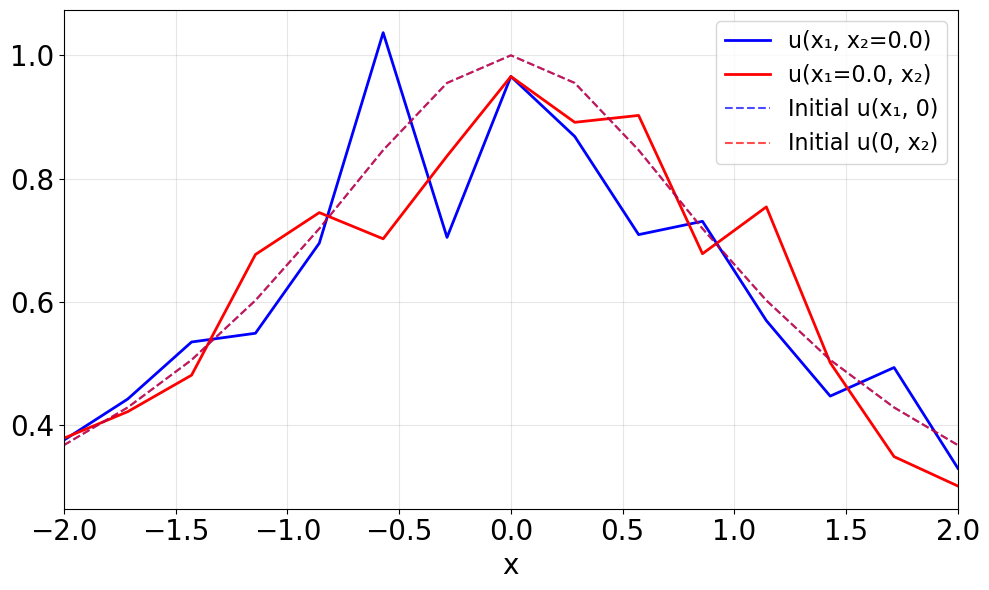

In [5]:
# Panel 3: Cross-sections through the center
fig, ax3 = plt.subplots(1, 1, figsize=(10, 6))
center_idx = nx1 // 2

# Cross-section along x1 axis at x2 = 0
x2_zero_idx = np.argmin(np.abs(x2))  # Find index closest to x2=0
cross_section_x1 = y_2d[:, x2_zero_idx]

# Cross-section along x2 axis at x1 = 0  
x1_zero_idx = np.argmin(np.abs(x1))  # Find index closest to x1=0
cross_section_x2 = y_2d[x1_zero_idx, :]

ax3.plot(x1, cross_section_x1, 'b-', label=f'u(x₁, x₂={x2[x2_zero_idx]:.1f})', linewidth=2)
ax3.plot(x2, cross_section_x2, 'r-', label=f'u(x₁={x1[x1_zero_idx]:.1f}, x₂)', linewidth=2)

# Add initial condition cross-sections for comparison
initial_cross_x1 = initial_2d[:, x2_zero_idx]
initial_cross_x2 = initial_2d[x1_zero_idx, :]
ax3.plot(x1, initial_cross_x1, 'b--', label='Initial u(x₁, 0)', alpha=0.7)
ax3.plot(x2, initial_cross_x2, 'r--', label='Initial u(0, x₂)', alpha=0.7)

ax3.set_xlabel('x')
# ax3.set_ylabel('u(t,x)')
# ax3.set_title('Cross-sections through center')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('2dplot2.png', format='png', dpi=150)
plt.show()

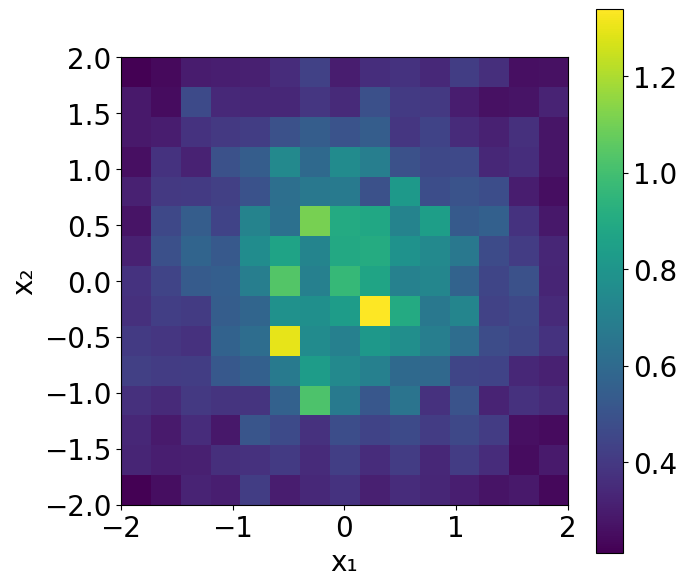

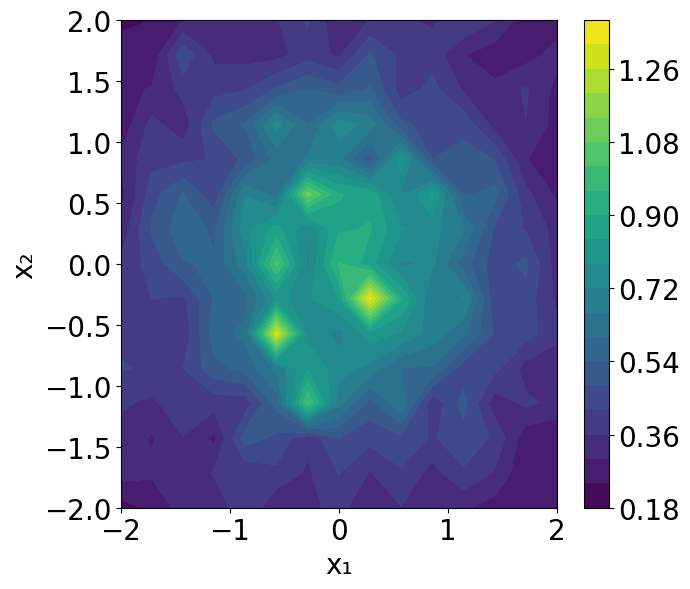

'\nprint("Running 10D case...")\nd=10\n\n#Space discretization - we consider points [x[1],0,0,...,0]\na=-2        #Interval [a,b] for x[1]\nb=2\nnx1=10      #Number of points in [a,b]\nx_10d=[[a+i*(b-a)/(nx1-1)] + [0]*9 for i in range(nx1)]    #Space discretization \n\n#MC solution\ny_10d = [mc_kpp_sol(alpha,gamma,lam,p,d,x_10d[i],T,n_iter) for i in range(len(x_10d))]\n\n#Plots\nplt.figure(figsize=(10, 6))\nplt.plot([x_10d[i][0] for i in range(nx1)], y_10d, \'bo-\', label="MC estimator", linewidth=2)\nplt.title(f"10D Time-Fractional F-KPP Equation\n"rf"$\x07lpha={alpha}, gamma={gamma}, lambda={lam}, t={T}$")\nplt.xlabel(r"$x_1$")\n# plt.ylabel(r"$u(t,x_1,0,...,0)$")\nplt.legend()\nplt.grid(True, alpha=0.3)\nplt.show()\n'

In [6]:
# # Additional 2D visualizations (heatmap and contour)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# # Heatmap
# im1 = ax1.imshow(y_2d.T, extent=[a, b, c, dd], origin='lower', cmap='viridis', aspect='equal')
# ax1.set_title(f'Heatmap - MC Solution at t = {T}')
# ax1.set_xlabel('x₁')
# ax1.set_ylabel('x₂')
# plt.colorbar(im1, ax=ax1)

# # Contour plot
# contour = ax2.contourf(X1, X2, y_2d, levels=20, cmap='viridis')
# ax2.set_title(f'Contour Plot - MC Solution at t = {T}')
# ax2.set_xlabel('x₁')
# ax2.set_ylabel('x₂')
# plt.colorbar(contour, ax=ax2)

# plt.tight_layout()
# plt.savefig('2dplot3.png', format='png', dpi=150)
# plt.show()

# print("2D visualization completed!")

fig1, ax1 = plt.subplots(figsize=(7,6))

im1 = ax1.imshow(
    y_2d.T,
    extent=[a, b, c, dd],
    origin='lower',
    cmap='viridis',
    aspect='equal'
)

# ax1.set_title(f'Heatmap - MC Solution at t = {T}')
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')

plt.colorbar(im1, ax=ax1)

plt.tight_layout()
plt.savefig('heatmap.png', format='png', dpi=150)
plt.show()

fig2, ax2 = plt.subplots(figsize=(7,6))

contour = ax2.contourf(
    X1, X2, y_2d,
    levels=20,
    cmap='viridis'
)

# ax2.set_title(f'Contour Plot - MC Solution at t = {T}')
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')

plt.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.savefig('contour.png', format='png', dpi=150)
plt.show()

############################################################################### 
#Example 3 - higher dimensions (optional, commented for speed)
"""
print("Running 10D case...")
d=10

#Space discretization - we consider points [x[1],0,0,...,0]
a=-2        #Interval [a,b] for x[1]
b=2
nx1=10      #Number of points in [a,b]
x_10d=[[a+i*(b-a)/(nx1-1)] + [0]*9 for i in range(nx1)]    #Space discretization 

#MC solution
y_10d = [mc_kpp_sol(alpha,gamma,lam,p,d,x_10d[i],T,n_iter) for i in range(len(x_10d))]

#Plots
plt.figure(figsize=(10, 6))
plt.plot([x_10d[i][0] for i in range(nx1)], y_10d, 'bo-', label="MC estimator", linewidth=2)
plt.title(f"10D Time-Fractional F-KPP Equation\n"rf"$\alpha={alpha}, gamma={gamma}, lambda={lam}, t={T}$")
plt.xlabel(r"$x_1$")
# plt.ylabel(r"$u(t,x_1,0,...,0)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
"""
